# Homework: Photometric reverberation mapping

In [1]:
import photRM
from pyzdcf import pyzdcf
from lc_proc import lc_proc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-deep')
plt.rcParams['font.size'] = 12

# Task 1

**Goal:**

- Understand the photometric reverberation mapping method and its limitations. 
- Introduction to the tools for simulating AGN light curves and performing photoRM.

<span style="color:blue">**a)**</span> Familiarize yourself with photRM module (read the docs located in photRM.py). Using the `lc_two_bands` function from the `photRM` module, construct **three pairs** of continuum and emission line light curves of length 5000 days. This is a hypothetical scenario where we generate pairs of light curves as if they are observed in two broadband filters:

   - one covering only continuum emission (we will name it *x-band*)
   - second covering emission line and the underlying continuum (we will name it *y-band*)

Make sure that the light curve pairs are simulated for the artificial AGN objects at z = 0.1 having luminosity (log L): 43, 44, and 45, respectively. The emission line contribution to the total integrated flux should be 25% and the continuum contribution 75% in all cases. Plot the first 1000 days of the light curves and compare the properties (printed when you run `lc_two_bands`) of these three simulated AGN objects. How would you explain the correlation between AGN luminosity and broad line region dimensions (i.e. time-lag)? Cut the light curve length to 1000 points and save them for later use.


In [2]:
x_band1, y_band1, line_response1 = photRM.lc_two_bands(5000,osc=True,z=0.1,lum=43,wl=0.25,wc=0.75)
print('\n')

x_band2, y_band2, line_response2 = photRM.lc_two_bands(5000,osc=True,z=0.1,lum=44,wl=0.25,wc=0.75)
print('\n')

x_band3, y_band3, line_response3 = photRM.lc_two_bands(5000,osc=True,z=0.1,lum=45,wl=0.25,wc=0.75)

Properties of the simulated AGN object:
---------------------------------------
log(L) = 43.00
MBH = 3.14e+06 M_sun
tau_DRW = 17.31 days
sigma_DRW = 0.05 mag^2/day
Time-lag = 9.86 days


Properties of the simulated AGN object:
---------------------------------------
log(L) = 44.00
MBH = 1.46e+07 M_sun
tau_DRW = 31.98 days
sigma_DRW = 0.03 mag^2/day
Time-lag = 33.65 days


Properties of the simulated AGN object:
---------------------------------------
log(L) = 45.00
MBH = 6.76e+07 M_sun
tau_DRW = 59.10 days
sigma_DRW = 0.01 mag^2/day
Time-lag = 114.82 days


In [3]:
lcs = [x_band1, y_band1, x_band2, y_band2, x_band3, y_band3]
lc_names = ['x_band1', 'y_band1', 'x_band2', 'y_band2', 'x_band3', 'y_band3']

# Cut the light curves to 1000 days
lcs_cut = [lc[:1000] for lc in lcs]

# Save the light curves for later use
input_dir = 'data/sim_lcs/'

for i, lc in enumerate(lcs_cut):
    np.savetxt(f'{input_dir}/lc_{lc_names[i]}.txt', lc, fmt='%.7e')


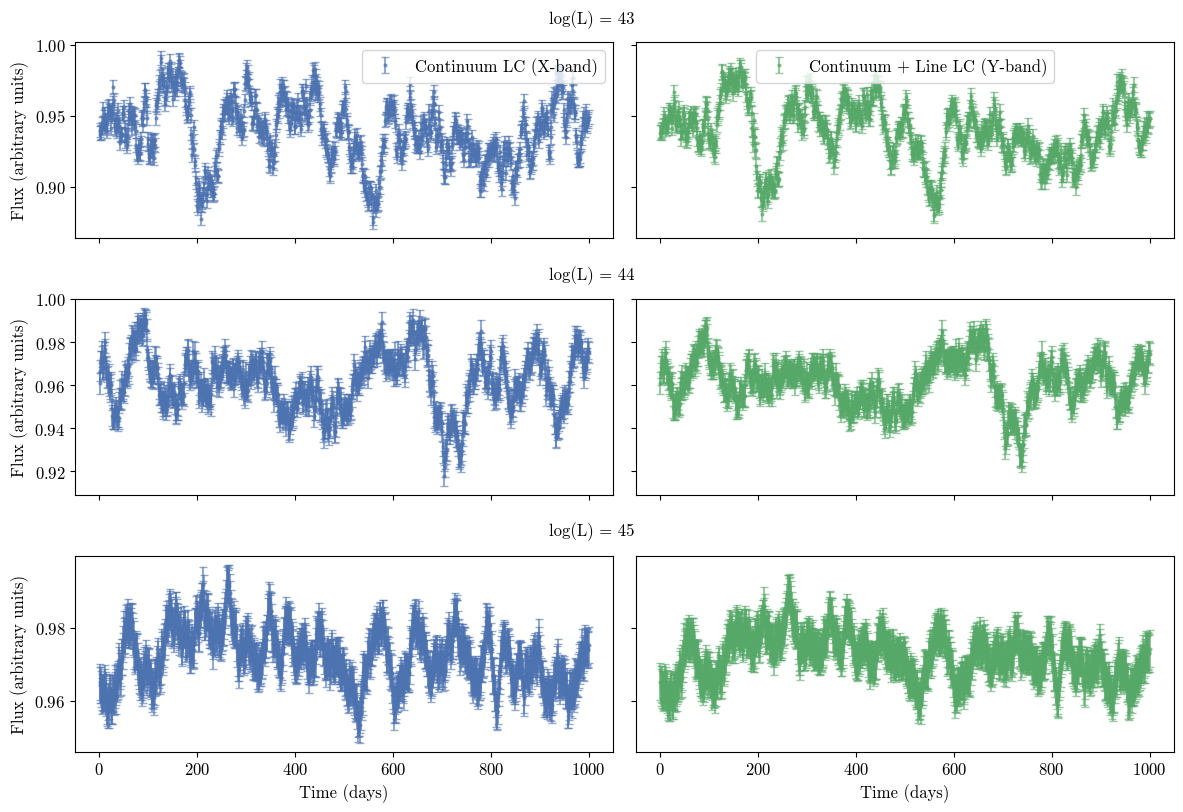

In [4]:
# Plot the light curves
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True,sharey=('row'))
labels = ['Continuum LC (X-band)', 'Continuum + Line LC (Y-band)']
colors = ['C0','C1']
for i, lc in enumerate(lcs_cut):
    ax = axes[i//2, i%2]
    ax.errorbar(lc['t'], lc['flux'], yerr=lc['err'],fmt='o',markersize=2,alpha=0.6,capsize=3, label=labels[i%2], color=colors[i%2])

luminosities = [43, 44, 45]
y_positions = [0.99, 0.67, 0.35]

for i, (lum, y) in enumerate(zip(luminosities, y_positions)):
    fig.text(0.5, y, f'log(L) = {lum}',
             ha='center', va='bottom')

axes[0, 0].legend()
axes[0, 1].legend()
axes[0, 0].set_ylabel('Flux (arbitrary units)')
axes[1, 0].set_ylabel('Flux (arbitrary units)')
axes[2, 0].set_ylabel('Flux (arbitrary units)')
axes[2, 0].set_xlabel('Time (days)')
axes[2, 1].set_xlabel('Time (days)')
plt.tight_layout(h_pad=3)
plt.show()


<span style="color:blue">**b)**</span> Using the photometric reverberation mapping method and the `pyzdcf` module, estimate the time-lag (broad line region radius) for these three light curve pairs. You can use the default values for keyword arguments in the function. How do the time-lag estimates compare to the values reported by `lc_two_bands`? You can estimate the time-lag using the `photRM.peak_finder` or (optionally) you can compile a Fortran code [PLIKE](https://www.weizmann.ac.il/particle/tal/research-activities/software) to obtain more accurate results and errors. Similarly display the results as in Astro Data Lab notebook.

In [5]:
import os

lc_files = [f for f in os.listdir(input_dir) if f.endswith('.txt')]
lc_files.sort()

print("Available light curve files:")
for f in lc_files:
    print(f)

Available light curve files:
lc_x_band1.txt
lc_x_band2.txt
lc_x_band3.txt
lc_y_band1.txt
lc_y_band2.txt
lc_y_band3.txt


In [6]:
output_dir = 'results/'

# Run pyzdcf
acf_1 = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  True, 
                                    prefix            = 'acf_1',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,  
                                    minpts            =  0,     
                                    num_MC            =  100,   
                                    lc1_name          =  'lc_x_band1.txt'    
                                    ))

acf_2 = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  True,
                                    prefix            = 'acf_2',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,  
                                    minpts            =  0,     
                                    num_MC            =  100,   
                                    lc1_name          =  'lc_x_band2.txt'    
                                    ))

acf_3 = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  True,
                                    prefix            = 'acf_3',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,  
                                    minpts            =  0,     
                                    num_MC            =  100,   
                                    lc1_name          =  'lc_x_band3.txt'    
                                    ))

ccf_1 = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  False,
                                    prefix            = 'ccf_1',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,  
                                    minpts            =  0,     
                                    num_MC            =  100,   
                                    lc1_name          =  'lc_x_band1.txt',    
                                    lc2_name          =  'lc_y_band1.txt'    
                                    ))

ccf_2 = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  False,
                                    prefix            = 'ccf_2',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,  
                                    minpts            =  0,     
                                    num_MC            =  100,   
                                    lc1_name          =  'lc_x_band2.txt',    
                                    lc2_name          =  'lc_y_band2.txt'    
                                    ))

ccf_3 = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  False,
                                    prefix            = 'ccf_3',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,  
                                    minpts            =  0,     
                                    num_MC            =  100,   
                                    lc1_name          =  'lc_x_band3.txt',    
                                    lc2_name          =  'lc_y_band3.txt'    
                                    ))


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs discarded.


acf_1.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs discarded.


acf_2.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs 

In [7]:
acfs = [acf_1, acf_2, acf_3]
ccfs = [ccf_1, ccf_2, ccf_3]

acfs = [photRM.add_inverted_acf(acf) for acf in acfs]
acfs = [photRM.interp(ccf,acf) for ccf, acf in zip(ccfs, acfs)]

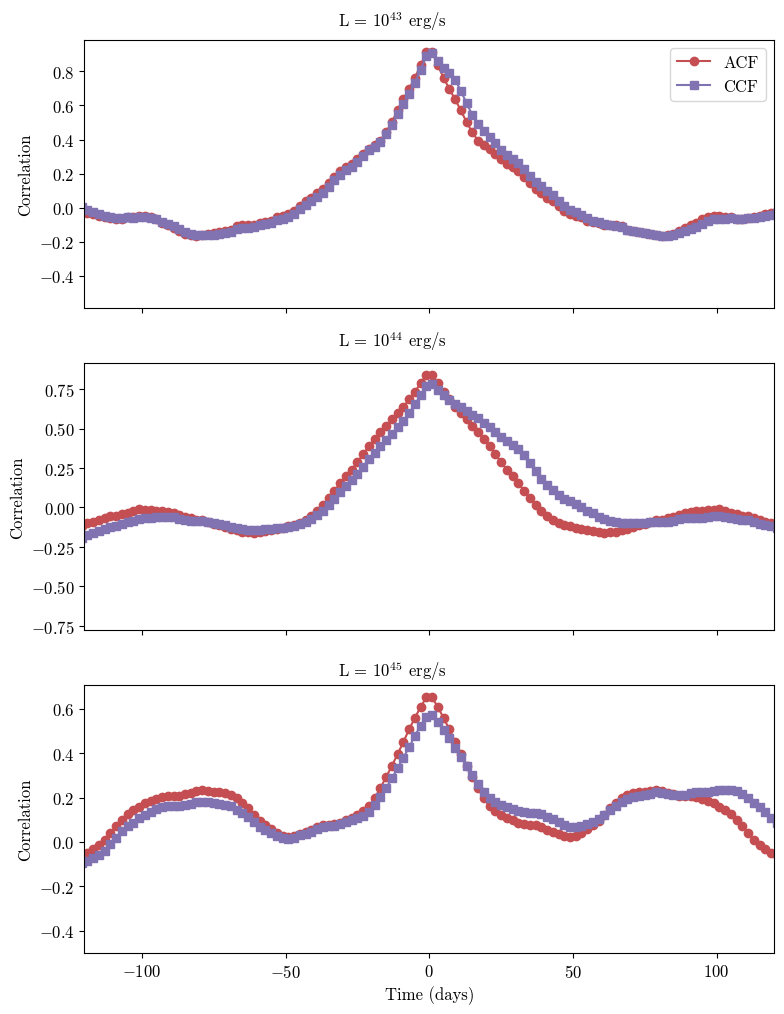

In [8]:
fig, axes = plt.subplots(3,1, figsize=(8, 10),sharex=True)

colors = ['C2','C3']

for i, (acf, ccf) in enumerate(zip(acfs, ccfs)):
    ax = axes[i]
    ax.plot(acf['tau'],acf['dcf'],'o-', label='ACF', color=colors[0])
    ax.plot(ccf['tau'],ccf['dcf'],'s-', label='CCF', color=colors[1])
    ax.set_xlim(-120,120)

luminosities = [43, 44, 45]
y_positions = [0.99, 0.67, 0.34]

for i, (lum, y) in enumerate(zip(luminosities, y_positions)):
    fig.text(0.5, y, rf'L = $10^{{{lum}}}$ erg/s',
             ha='center', va='bottom', fontsize=12)

axes[0].legend()
axes[2].set_xlabel('Time (days)')
axes[0].set_ylabel('Correlation')
axes[1].set_ylabel('Correlation')
axes[2].set_ylabel('Correlation')
plt.tight_layout(h_pad=3)
plt.show()

In [9]:
final_ccfs = [photRM.delta_ccf(acf,ccf) for acf, ccf in zip(acfs, ccfs)]

In [10]:
tau1, peaks_x1, peaks_y1 = photRM.peak_finder(final_ccfs[0].dcf.values,final_ccfs[0].tau.values,(0,50))
tau2, peaks_x2, peaks_y2 = photRM.peak_finder(final_ccfs[1].dcf.values,final_ccfs[1].tau.values,(0,100))
tau3, peaks_x3, peaks_y3 = photRM.peak_finder(final_ccfs[2].dcf.values,final_ccfs[2].tau.values,(0,150))

Peak candidates (x-axis vals):  [ 9. 37.]
Max. peak:  9.0
Peak candidates (x-axis vals):  [33.]
Max. peak:  33.0
Peak candidates (x-axis vals):  [ 39. 115.]
Max. peak:  115.0


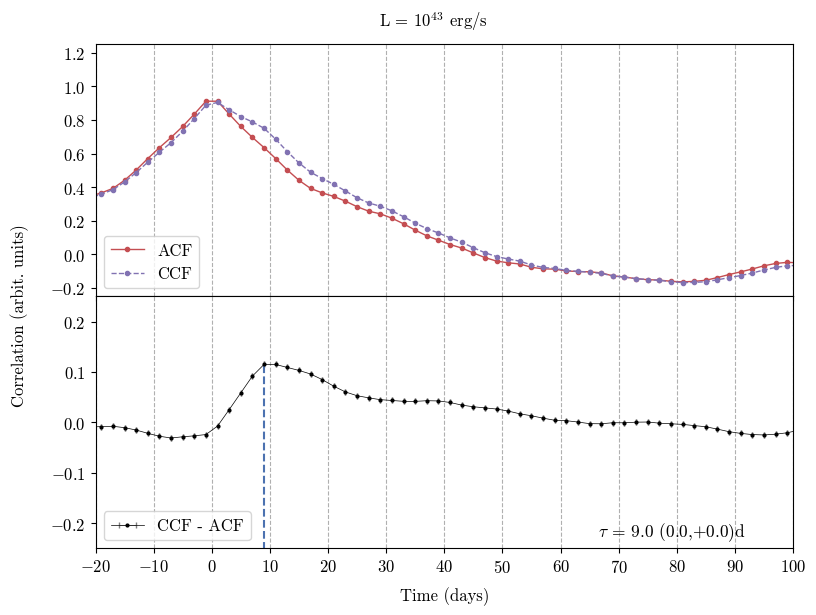

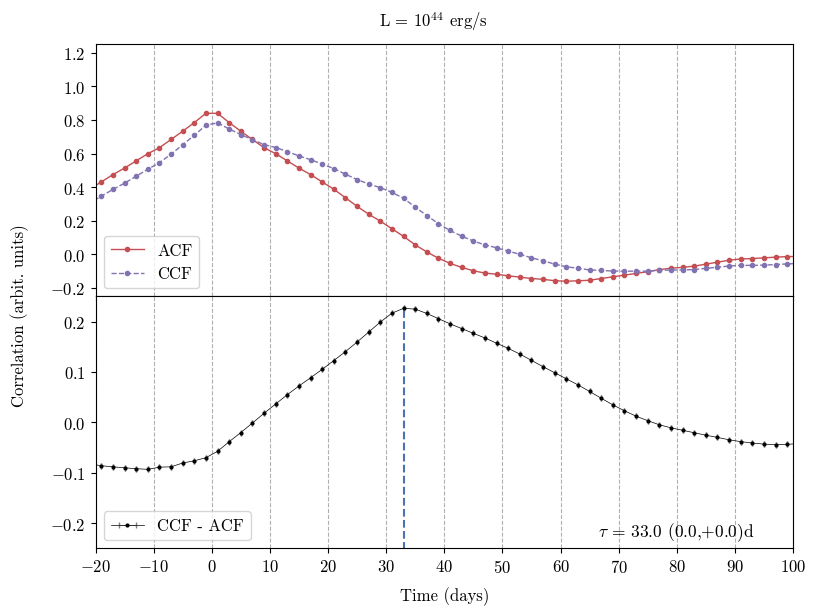

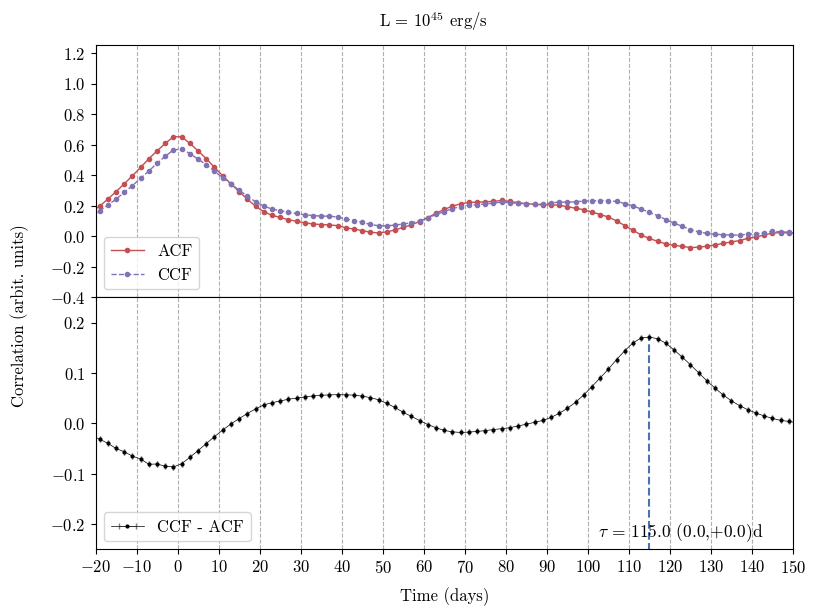

In [11]:
photRM.plot_ccf_acf(final_ccfs[0],ccfs[0],acfs[0],locator=10,peak=True,tau=tau1,lims_x=(-20,100),title='L = $10^{43}$ erg/s')
photRM.plot_ccf_acf(final_ccfs[1],ccfs[1],acfs[1],locator=10,peak=True,tau=tau2,lims_x=(-20,100),title='L = $10^{44}$ erg/s')
photRM.plot_ccf_acf(final_ccfs[2],ccfs[2],acfs[2],locator=10,peak=True,tau=tau3,lims_x=(-20,150),lims_y=(-0.4,1.25),title='L = $10^{45}$ erg/s')

Time-lag comparison

|log(L) | Simulated | Estimated |
|- | --| --|
|43 | 9.86 | 9|
|44| 33.65 | 33|
| 45 | 114.82 | 115 |

The estimated time-lag obtained with the photo RM method is in good agreement with the displayed from the simulated LCs

# Task 2

**Goal:** Apply photometric reverberation mapping to real-world data.

Download photometric light curves of NGC 4395 from Edri et al. (2012). Choose one filter which covers the continuum emission only and the other one that covers the $\text{H}\alpha$ emission line and the underlying continuum. Using the utility functions provided, process the data so that time is expressed in hours and line intensity and its error are expressed as normalized flux. Plot the light curves. You will see that they are divided into segments because we have a pause in observations during the daylight. Choose the first segment and estimate the time lag using this data. Compare your results to Edri et al. (2012) and discuss the pros and cons of photometric reverberation mapping compared to spectroscopic reverberation mapping.

From Edri et. al. 2012 we can see that the 'g' band includes the $\text{H}\alpha$ line, the 'r' band includes $\text{H}\beta$ and the 'i' band includes mostly continuum

<img src="obs_spectrum_edri2012.png" width="800">

In [12]:
# Read the light curves
lc_r = pd.read_csv('data/obs_data/lc_r.txt', header=0, sep=" ", skipinitialspace=True, usecols=[0,1,2])
lc_i = pd.read_csv('data/obs_data/lc_i.txt', header=0, sep=" ", skipinitialspace=True, usecols=[0,1,2])

In [13]:
# Light curve processing utility function
obs_lcs = [lc_r, lc_i]
filters = ['r', 'i'] # see lc_proc docs for accepted values for filters
new_lcs = lc_proc(obs_lcs, filters)

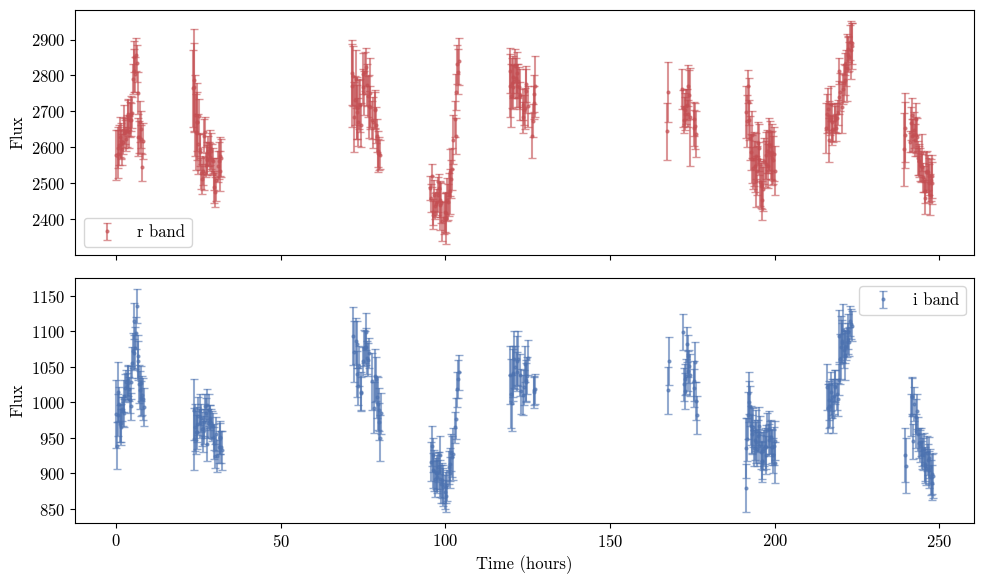

In [14]:
# Plot the light curves
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,sharey=('row'))
labels = ['r band','i band']
colors = ['C2','C0']
for i, lc in enumerate(new_lcs):
    ax = axes[i]
    ax.errorbar(lc['time_hours'], lc['flux'], yerr=lc['flux_err'],fmt='o',markersize=2,alpha=0.6,capsize=3, label=labels[i], color=colors[i])
    ax.legend()

axes[0].set_ylabel('Flux')
axes[1].set_ylabel('Flux')
axes[1].set_xlabel('Time (hours)')
plt.tight_layout()
plt.show()

First segment

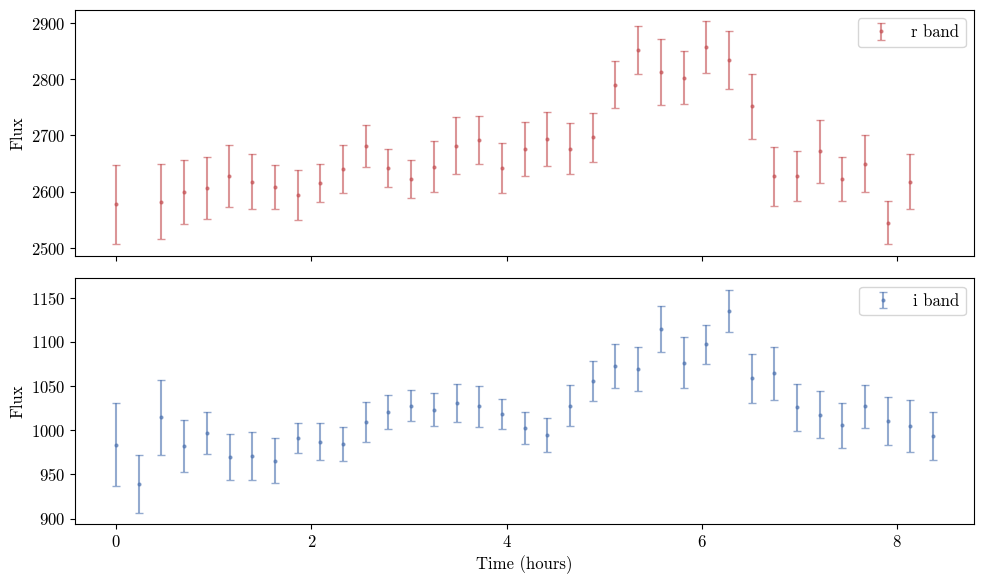

In [15]:
new_lcs_cut = [new_lcs[0][:35], new_lcs[1][:37]]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i, lc in enumerate(new_lcs_cut):
    ax = axes[i]
    ax.errorbar(lc['time_hours'], lc['flux'], yerr=lc['flux_err'],fmt='o',markersize=2,alpha=0.6,capsize=3, label=labels[i], color=colors[i])
    ax.legend()

axes[0].set_ylabel('Flux')
axes[1].set_ylabel('Flux')
axes[1].set_xlabel('Time (hours)')
plt.tight_layout()
plt.show()

# Save the processed light curves for later use
input_dir = 'data/obs_data/'
for i, lc in enumerate(new_lcs_cut):
    np.savetxt(f'{input_dir}cut_lc_{filters[i]}.txt', np.column_stack((lc['time_hours'], lc['flux'], lc['flux_err'])), fmt=['%.1f','%.7e','%.7e'])

In [16]:
output_dir = 'results/'

acf_i = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  True, 
                                    prefix            = 'acf_i',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,  
                                    minpts            =  0,     
                                    num_MC            =  100,   
                                    lc1_name          =  'cut_lc_i.txt'    
                                    ))

ccf_ir = pyzdcf(input_dir,output_dir,intr=False, sep=' ',sparse='auto',
                    parameters = dict(autocf =  False,
                                    prefix            = 'ccf_ig',  
                                    uniform_sampling  =  False, 
                                    omit_zero_lags    =  True,
                                    minpts            =  0,
                                    num_MC            =  100,
                                    lc1_name          =  'cut_lc_i.txt',
                                    lc2_name          =  'cut_lc_r.txt'    
                                    ))


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

35 bins actually used, 45.0 inter-dependent pairs discarded.


acf_i.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

64 bins actually used, 164 inter-dependent pairs discarded.


ccf_ig.dcf written...

pyZDCF ended.



In [17]:
acf_i = photRM.add_inverted_acf(acf_i)

acf_ir = photRM.interp(ccf_ir, acf_i)

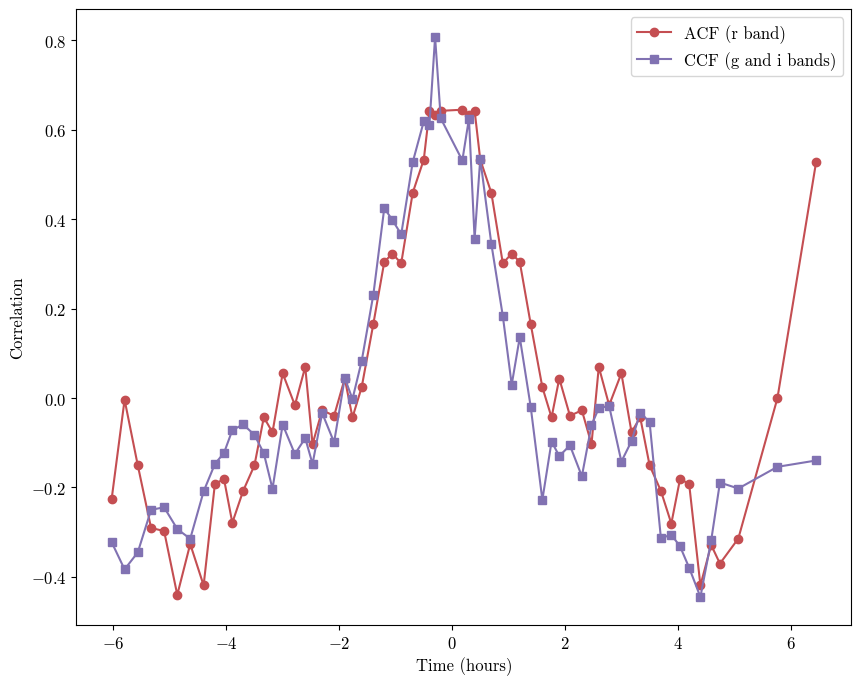

In [18]:
plt.figure(figsize=(10, 8))

colors = ['C2','C3']

plt.plot(acf_ir['tau'],acf_ir['dcf'],'o-', label='ACF (r band)', color=colors[0])
plt.plot(ccf_ir['tau'],ccf_ir['dcf'],'s-', label='CCF (g and i bands)', color=colors[1])
plt.legend()

plt.xlabel('Time (hours)')
plt.ylabel('Correlation')
plt.show()

In [19]:
diff_ir = photRM.delta_ccf(acf_ir, ccf_ir)

tau_ir, peaks_x_ir, peaks_y_ir = photRM.peak_finder(diff_ir.dcf.values, diff_ir.tau.values, (0, 5))

Peak candidates (x-axis vals):  [0.30000001 0.5        1.20000005 1.76315788 2.0888888  2.47058826
 2.7833333  3.5        3.88461546]
Max. peak:  3.5


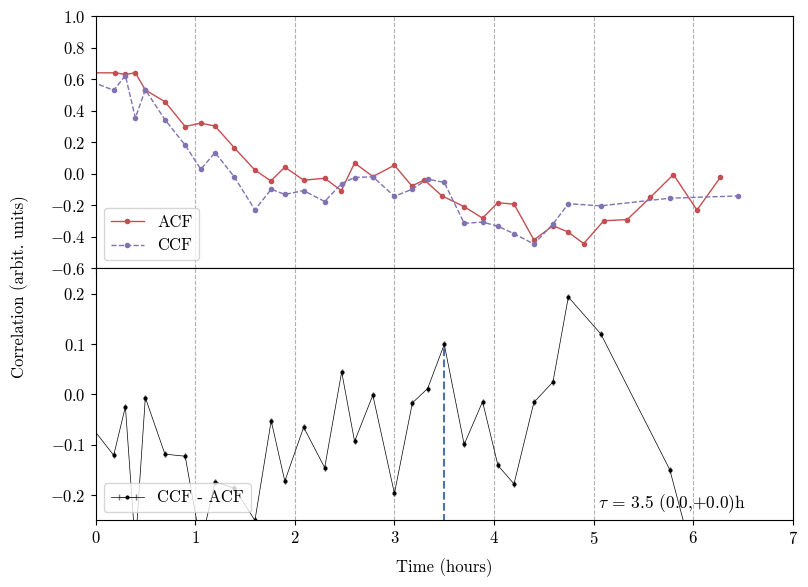

In [20]:
photRM.plot_ccf_acf(diff_ir, ccf_ir, acf_i, locator=1, peak=True, tau=tau_ir, lims_x=(0, 7),lims_y=(-0.6,1),time='hours')

In the Edri et al. 2012 they find the time lag between $\text{H}\alpha$ and the continuum to be 3.46 hours, which is consitent with the result obtained in this notebook of 3.5 hours. However, it is important to note that this result changes if the interval to search for the peaks is increased.

# References:

- Edri et al. (2012) https://ui.adsabs.harvard.edu/abs/2012ApJ...756...73E/abstract
- Jankov et al. (2022) https://ui.adsabs.harvard.edu/abs/2022AN....34310090J/abstract
- Kovacevic et al. (2021) https://ui.adsabs.harvard.edu/abs/2021MNRAS.505.5012K/abstract
- [Astro Data Lab](https://datalab.noirlab.edu/)
- [pyzdcf documentation](https://pyzdcf.readthedocs.io/en/latest/?badge=latest)
- [PLIKE download link](https://www.weizmann.ac.il/particle/tal/research-activities/software)